https://www.nature.com/articles/s41586-021-03569-1

In [78]:
%load_ext autoreload
%autoreload 2

import sys, os

# Add parent directory to Python path
sys.path.append(os.path.abspath(".."))  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
from scrna_pipeline.utils import per_sample_export

In [80]:


# report = per_sample_export.export_per_sample_h5ads(
#     "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/GSE171524_RAW_merged.h5ad",
#     "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw",
#     sample_key="sample",      # <-- your obs column

#     filename_suffix="raw",
# )
# print(report.n_cells_per_sample)


In [81]:


BROAD_MARKERS = {
    # ----------------------------- Epithelial -----------------------------
    "Airway epithelial cells": [
        "EPCAM",      # pan-epithelial
        "KRT8", "KRT18",  # luminal epithelial
        "SCGB1A1",        # club/secretory
        "FOXJ1"           # ciliated epithelial program
    ],

    "AT1": [
        "AGER", 
        "PDPN", 
        "CAV1",
        "CLDN18",
        "AQP5"
    ],

    "AT2": [
        "SFTPC",
        "SFTPB",
        "SFTPA1",
        "ABCA3",
        "SLC34A2"
    ],

    "Other epithelial cells": [
        "EPCAM",         # baseline epithelial identity
        "KRT19",         # luminal cytokeratin
        "MUC1",          # surface mucin
        "KRT8", "KRT18"
    ],

    # ----------------------------- Immune (Adaptive) -----------------------------
    "B cells": [
        "MS4A1",        # CD20
        "CD79A",
        "CD79B",
        "CD74",
        "BANK1"
    ],

    "Plasma cells": [
        "JCHAIN",
        "MZB1",
        "SDC1",          # CD138
        "IGHG1",
        "PRDM1"
    ],

    "CD4+ T cells": [
        "IL7R",
        "CCR7",
        "TCF7",
        "LTB",
        "MAL"
    ],

    "CD8+ T cells": [
        "CD8A",
        "CD8B",
        "GZMK",
        "CCL5",
        "TRAC"
    ],

    "Tregs": [
        "FOXP3",
        "IL2RA",
        "CTLA4",
        "IKZF2",
        "TNFRSF18"
    ],

    # ----------------------------- Immune (Innate) -----------------------------
    "NK cells": [
        "GNLY",
        "NKG7",
        "PRF1",
        "GZMB",
        "KLRD1"
    ],

    "Cycling NK/T cells": [
        "MKI67",
        "TOP2A",
        "CENPF",
        "ASPM",
        "BIRC5"
    ],

    "Monocytes": [
        "LYZ",
        "S100A8",
        "S100A9",
        "FCN1",
        "CTSS"
    ],

    "Macrophages": [
        "C1QA",
        "C1QB",
        "C1QC",
        "MRC1",
        "APOE"
    ],

    "Dendritic cells": [
        "ITGAX",         # CD11c
        "CD1C",          # cDC2
        "CLEC9A",        # cDC1
        "LILRA4",        # pDC
        "HLA-DRA"
    ],

    "Mast cells": [
        "KIT",
        "TPSAB1",
        "TPSB2",
        "CPA3",
        "HDC"
    ],

    # ----------------------------- Stromal & Vascular -----------------------------
    "Fibroblasts": [
        "COL1A1",
        "COL1A2",
        "COL3A1",
        "DCN",
        "LUM"
    ],

    "Smooth muscle": [
        "ACTA2",
        "MYH11",
        "TAGLN",
        "RGS5",
        "PDGFRB"
    ],

    "Endothelial cells": [
        "VWF",
        "PECAM1",        # CD31
        "CDH5",          # VE-cadherin
        "KDR",
        "ESAM"
    ],

    # ----------------------------- Nervous system -----------------------------
    "Neuronal cells": [
        "RBFOX3",        # NeuN
        "TUBB3",         # β3-tubulin
        "MAP2",
        "SNAP25",
        "SYT1"
    ],
}


In [82]:
import scanpy as sc

from scrna_pipeline.core.pipeline import StepContext, run_steps
from scrna_pipeline.pipelines.standard_per_sample import standard_per_sample_pipeline

# 1) Load one raw per-sample h5ad
adata = sc.read_h5ad("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226595_L16cov.raw.h5ad")



# 2) Build the step list (strict workflow)
steps = standard_per_sample_pipeline(
    batch_key="batch",          # must exist in adata.obs
    marker_dict=BROAD_MARKERS,  # your dict[str, list[str]]
    # optional: override defaults if you want
    # n_top_genes=2000, n_pcs=50, n_neighbors=15, resolution=0.6, ...
)

# 3) Execute steps
ctx = StepContext(verbose=True, strict=True)
adata = run_steps(adata, steps, ctx=ctx)

adata


[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226595_L16cov kept 1374/1822 | max_genes=3032, max_counts=6627, max_mito=7.37
[QC filter] removed 448 cells; remaining 1374
Running Scrublet for doublet detection...
Removed 4 predicted doublets
After doublet removal: (1370, 19457)
[steps] 01/03 preprocess_to_pca: done (0.69s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (1.13s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.21s)


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


AnnData object with n_obs × n_vars = 1370 × 19457
    obs: 'sample', 'file', 'batch', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'broad_Airway epithelial cells_score', 'broad_AT1_score', 'broad_AT2_score', 'broad_Other epithelial cells_score', 'broad_B cells_score', 'broad_Plasma cells_score', 'broad_CD4+ T cells_score', 'broad_CD8+ T cells_score', 'broad_Tregs_score', 'broad_NK cells_score', 'broad_Cycling NK/T cells_score', 'broad_Monocytes_score', 'broad_Macrophages_score', 'broad_Dendritic cells_score', 'broad_Mast cells_score', 'broad_Fibroblasts_score', 'broad_Smooth muscle_score', 'broad_Endothelial cells_score', 'broad

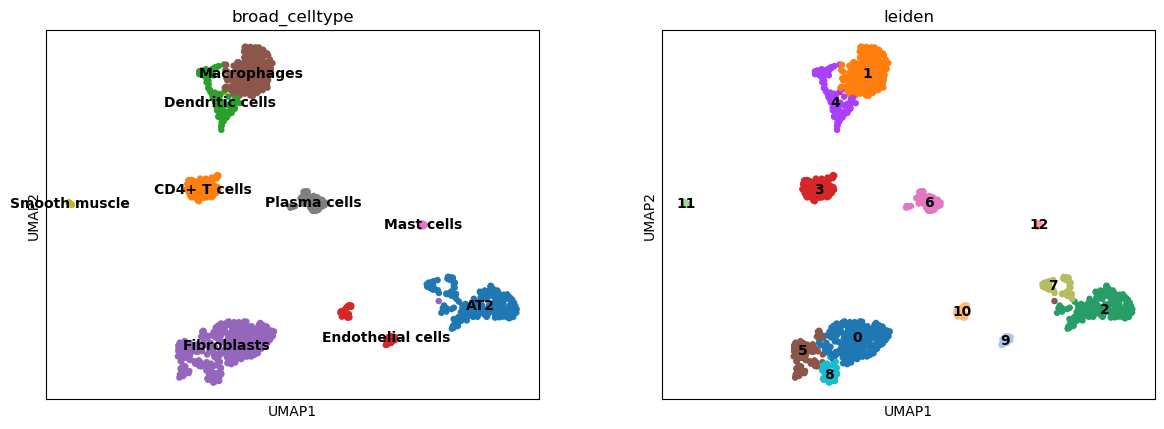

In [83]:
sc.pl.umap(adata, color=["broad_celltype", "leiden"], legend_loc="on data")


# Full Batch

In [84]:
from anndata import AnnData
import scanpy as sc

def show_umap_summary(name: str, adata: AnnData) -> None:
  
    print(f"\n### Sample: {name}")
    sc.pl.umap(
        adata,
        color=["broad_celltype", "leiden"],
        legend_loc="on data",
        show=True,
        ncols = 2,
        
    )


=== [GSM5226574_C51ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226574_C51ctr.raw.h5ad ===

=== [GSM5226574_C51ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226574_C51ctr kept 5102/6099 | max_genes=3266, max_counts=7394, max_mito=3.27
[QC filter] removed 997 cells; remaining 5102
Running Scrublet for doublet detection...
Removed 8 predicted doublets
After doublet removal: (5094, 24660)
[steps] 01/03 preprocess_to_pca: done (10.35s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (5.03s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.48s)

### Sample: GSM5226574_C51ctr.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


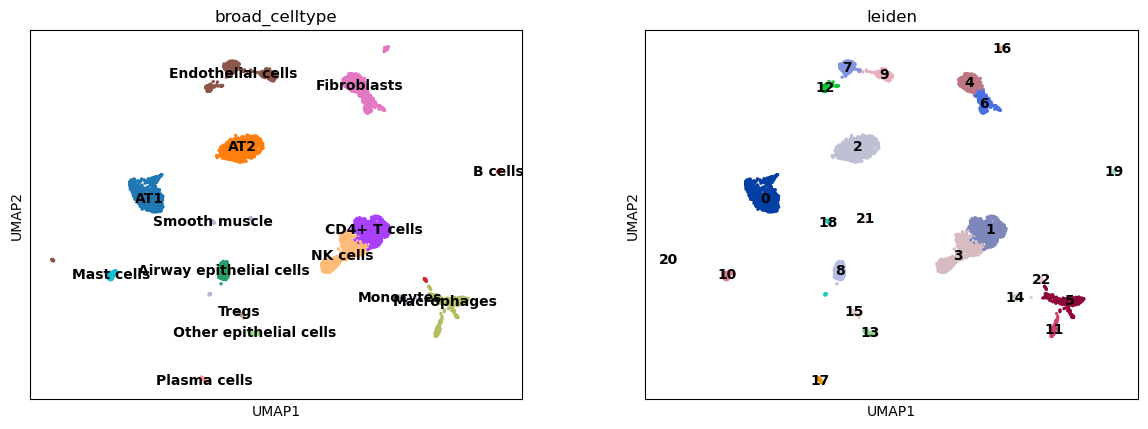

=== [GSM5226574_C51ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226574_C51ctr.raw.processed.h5ad (50.3 MB) ===

=== [GSM5226575_C52ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226575_C52ctr.raw.h5ad ===

=== [GSM5226575_C52ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226575_C52ctr kept 3770/4513 | max_genes=3404, max_counts=9184, max_mito=7.07
[QC filter] removed 743 cells; remaining 3770
Running Scrublet for doublet detection...
Removed 26 predicted doublets
After doublet removal: (3744, 22861)
[steps] 01/03 preprocess_to_pca: done (7.05s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (3.29s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.40s)

### Sample: GSM5226575_C52ctr.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


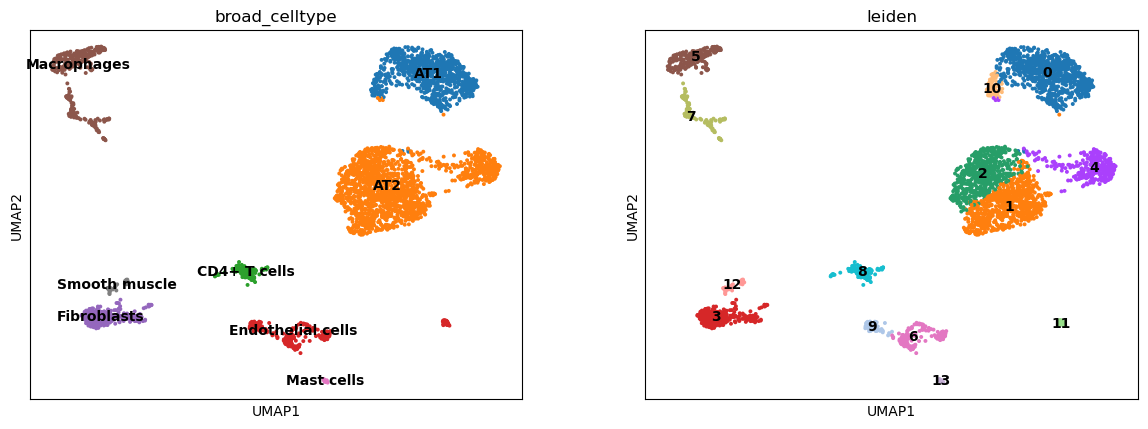

=== [GSM5226575_C52ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226575_C52ctr.raw.processed.h5ad (39.0 MB) ===

=== [GSM5226576_C53ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226576_C53ctr.raw.h5ad ===

=== [GSM5226576_C53ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226576_C53ctr kept 5734/7120 | max_genes=3566, max_counts=8631, max_mito=5.32
[QC filter] removed 1386 cells; remaining 5734
Running Scrublet for doublet detection...
Removed 70 predicted doublets
After doublet removal: (5664, 25509)
[steps] 01/03 preprocess_to_pca: done (11.53s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (5.47s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.53s)

### Sample: GSM5226576_C53ctr.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


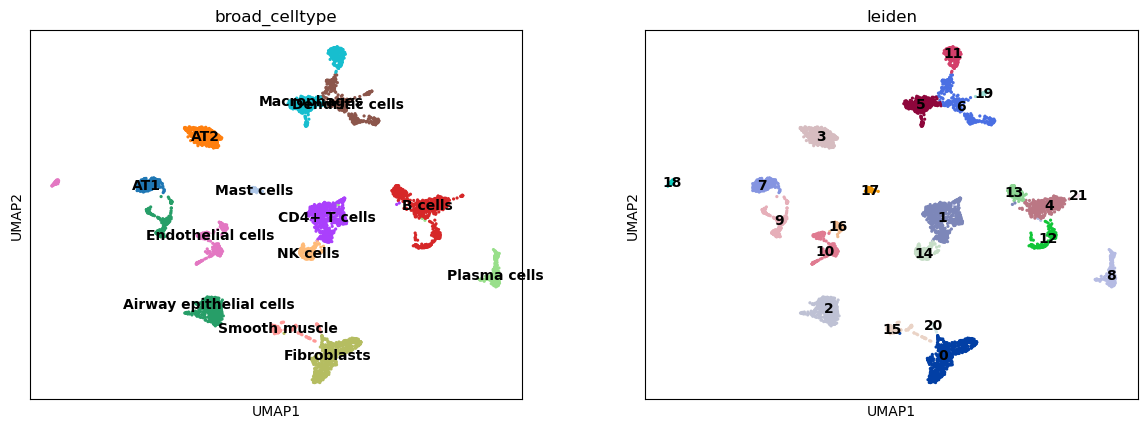

=== [GSM5226576_C53ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226576_C53ctr.raw.processed.h5ad (55.5 MB) ===

=== [GSM5226577_C54ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226577_C54ctr.raw.h5ad ===

=== [GSM5226577_C54ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226577_C54ctr kept 3442/4382 | max_genes=2598, max_counts=5483, max_mito=5.15
[QC filter] removed 940 cells; remaining 3442
Running Scrublet for doublet detection...
Removed 15 predicted doublets
After doublet removal: (3427, 21928)
[steps] 01/03 preprocess_to_pca: done (7.01s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (3.06s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.31s)

### Sample: GSM5226577_C54ctr.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


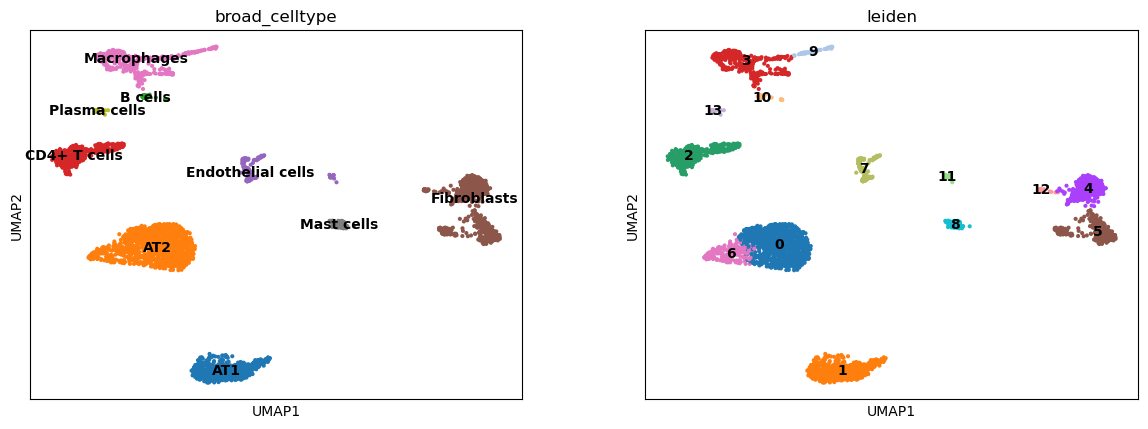

=== [GSM5226577_C54ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226577_C54ctr.raw.processed.h5ad (27.8 MB) ===

=== [GSM5226578_C55ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226578_C55ctr.raw.h5ad ===

=== [GSM5226578_C55ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226578_C55ctr kept 4293/5685 | max_genes=2104, max_counts=4353, max_mito=2.98
[QC filter] removed 1392 cells; remaining 4293
Running Scrublet for doublet detection...
Removed 40 predicted doublets
After doublet removal: (4253, 22580)
[steps] 01/03 preprocess_to_pca: done (7.74s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (4.51s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.34s)

### Sample: GSM5226578_C55ctr.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


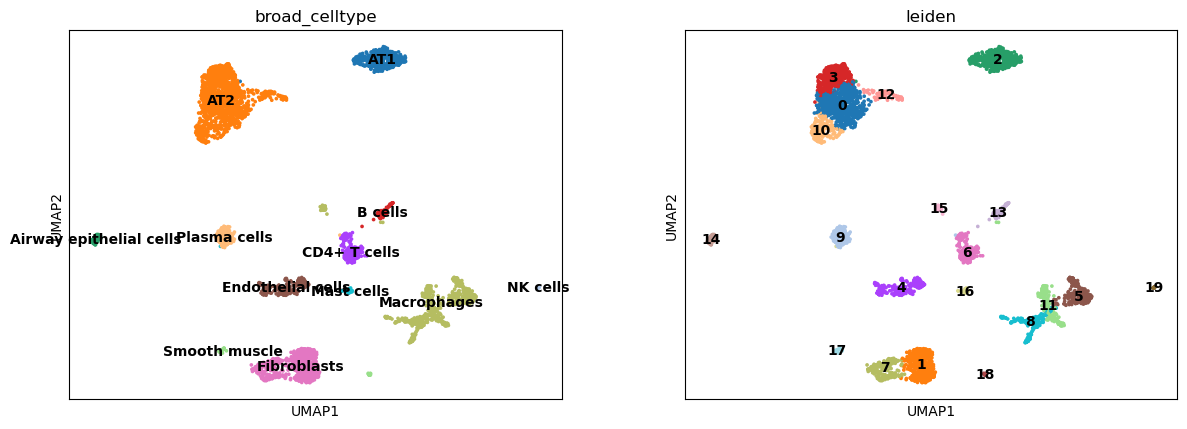

=== [GSM5226578_C55ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226578_C55ctr.raw.processed.h5ad (31.6 MB) ===

=== [GSM5226579_C56ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226579_C56ctr.raw.h5ad ===

=== [GSM5226579_C56ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226579_C56ctr kept 3285/4090 | max_genes=3716, max_counts=8071, max_mito=6.37
[QC filter] removed 805 cells; remaining 3285
Running Scrublet for doublet detection...
Removed 7 predicted doublets
After doublet removal: (3278, 22511)
[steps] 01/03 preprocess_to_pca: done (6.09s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.75s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.35s)

### Sample: GSM5226579_C56ctr.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


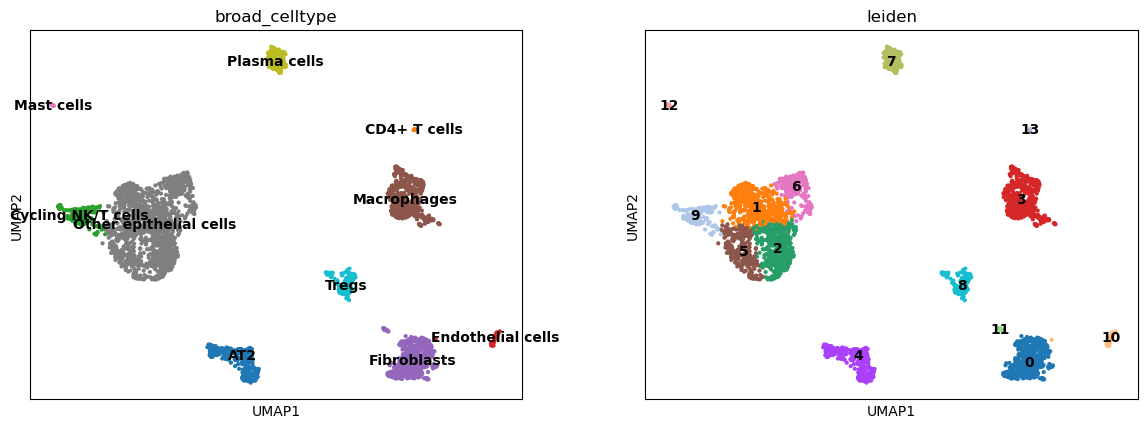

=== [GSM5226579_C56ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226579_C56ctr.raw.processed.h5ad (31.7 MB) ===

=== [GSM5226580_C57ctr.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226580_C57ctr.raw.h5ad ===

=== [GSM5226580_C57ctr.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226580_C57ctr kept 3921/4789 | max_genes=2814, max_counts=5114, max_mito=3.68
[QC filter] removed 868 cells; remaining 3921
Running Scrublet for doublet detection...
Removed 22 predicted doublets
After doublet removal: (3899, 22628)
[steps] 01/03 preprocess_to_pca: done (6.96s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (3.61s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.35s)

### Sample: GSM5226580_C57ctr.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


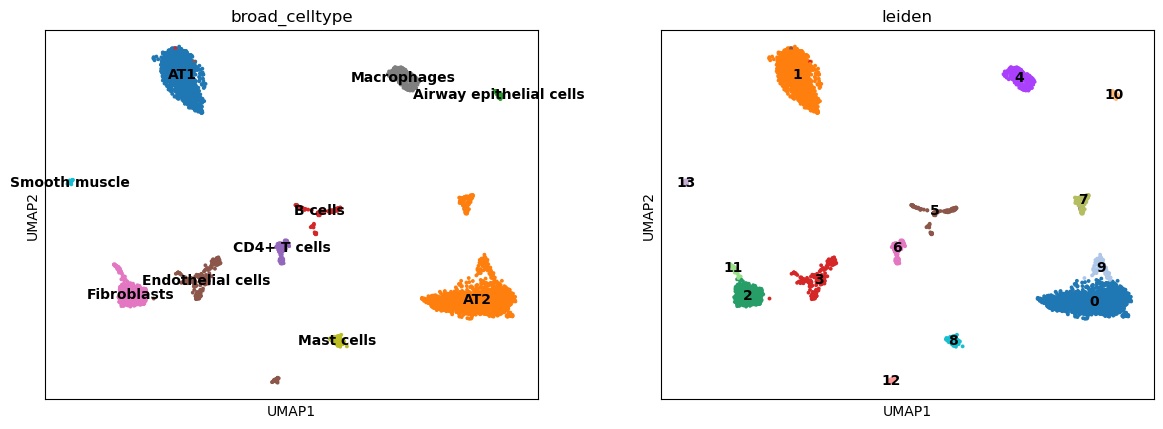

=== [GSM5226580_C57ctr.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226580_C57ctr.raw.processed.h5ad (32.3 MB) ===

=== [GSM5226581_L01cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226581_L01cov.raw.h5ad ===

=== [GSM5226581_L01cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226581_L01cov kept 2371/3060 | max_genes=3230, max_counts=6774, max_mito=5.56
[QC filter] removed 689 cells; remaining 2371
Running Scrublet for doublet detection...
Removed 8 predicted doublets
After doublet removal: (2363, 21026)
[steps] 01/03 preprocess_to_pca: done (1.09s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.02s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.25s)

### Sample: GSM5226581_L01cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


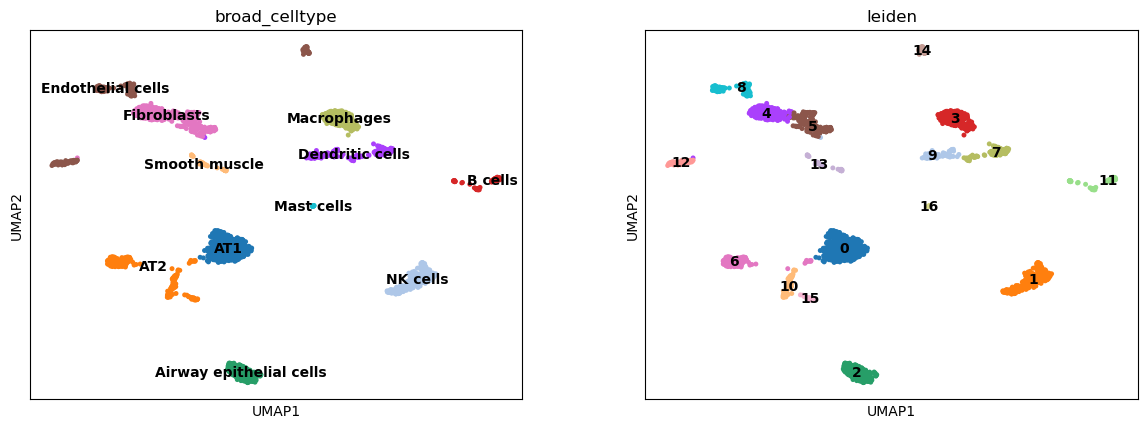

=== [GSM5226581_L01cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226581_L01cov.raw.processed.h5ad (21.4 MB) ===

=== [GSM5226582_L03cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226582_L03cov.raw.h5ad ===

=== [GSM5226582_L03cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226582_L03cov kept 4469/5060 | max_genes=6192, max_counts=20546, max_mito=3.28
[QC filter] removed 591 cells; remaining 4469
Running Scrublet for doublet detection...
Removed 26 predicted doublets
After doublet removal: (4443, 25300)
[steps] 01/03 preprocess_to_pca: done (9.31s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (4.61s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.69s)

### Sample: GSM5226582_L03cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


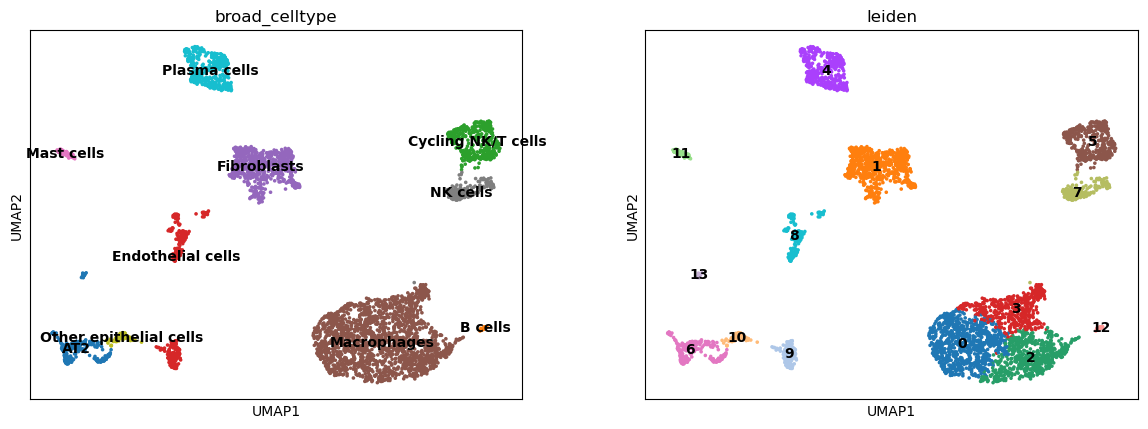

=== [GSM5226582_L03cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226582_L03cov.raw.processed.h5ad (76.6 MB) ===

=== [GSM5226583_L04cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226583_L04cov.raw.h5ad ===

=== [GSM5226583_L04cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226583_L04cov kept 2790/3630 | max_genes=2557, max_counts=4692, max_mito=3.83
[QC filter] removed 840 cells; remaining 2790
Running Scrublet for doublet detection...
Removed 7 predicted doublets
After doublet removal: (2783, 20596)
[steps] 01/03 preprocess_to_pca: done (5.05s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.31s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.26s)

### Sample: GSM5226583_L04cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


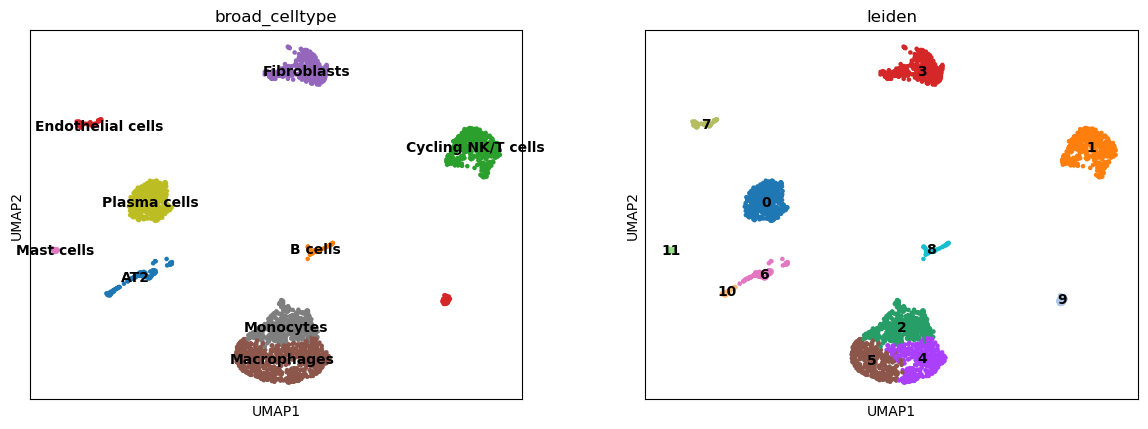

=== [GSM5226583_L04cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226583_L04cov.raw.processed.h5ad (22.9 MB) ===

=== [GSM5226584_L04covaddon.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226584_L04covaddon.raw.h5ad ===

=== [GSM5226584_L04covaddon.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226584_L04covaddon kept 3886/4574 | max_genes=3408, max_counts=7873, max_mito=4.88
[QC filter] removed 688 cells; remaining 3886
Running Scrublet for doublet detection...
Removed 7 predicted doublets
After doublet removal: (3879, 23082)
[steps] 01/03 preprocess_to_pca: done (7.24s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (3.28s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.47s)

### Sample: GSM5226584_L04covaddon.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


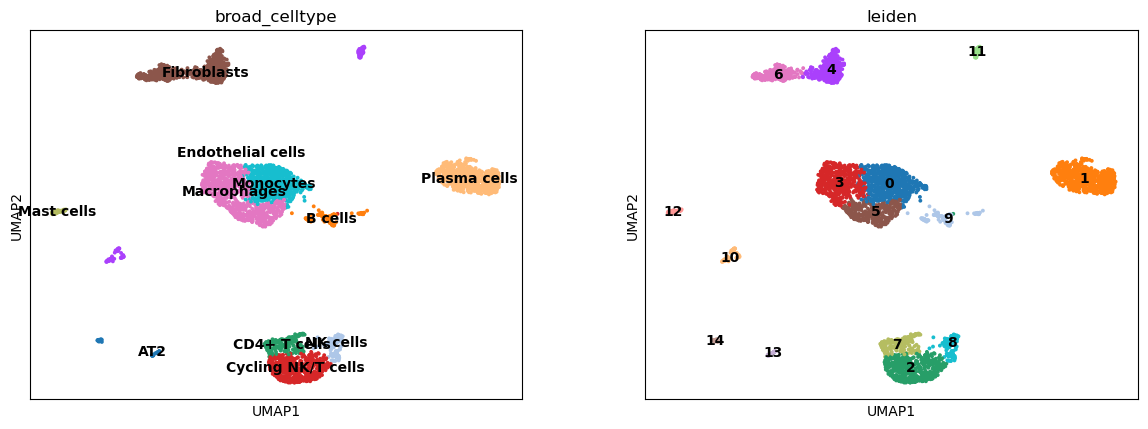

=== [GSM5226584_L04covaddon.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226584_L04covaddon.raw.processed.h5ad (42.6 MB) ===

=== [GSM5226585_L05cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226585_L05cov.raw.h5ad ===

=== [GSM5226585_L05cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226585_L05cov kept 2497/3052 | max_genes=3331, max_counts=6665, max_mito=3.65
[QC filter] removed 555 cells; remaining 2497
Running Scrublet for doublet detection...
Removed 10 predicted doublets
After doublet removal: (2487, 20665)
[steps] 01/03 preprocess_to_pca: done (1.63s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.04s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.29s)

### Sample: GSM5226585_L05cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


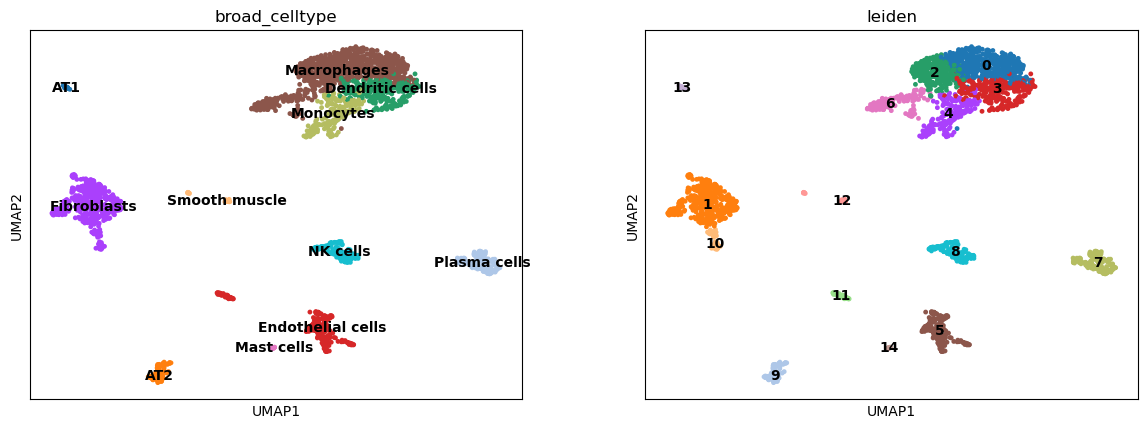

=== [GSM5226585_L05cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226585_L05cov.raw.processed.h5ad (25.8 MB) ===

=== [GSM5226586_L06cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226586_L06cov.raw.h5ad ===

=== [GSM5226586_L06cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226586_L06cov kept 5832/7582 | max_genes=3903, max_counts=9273, max_mito=5.56
[QC filter] removed 1750 cells; remaining 5832
Running Scrublet for doublet detection...
Removed 49 predicted doublets
After doublet removal: (5783, 23592)
[steps] 01/03 preprocess_to_pca: done (1064.08s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (5.57s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.53s)

### Sample: GSM5226586_L06cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


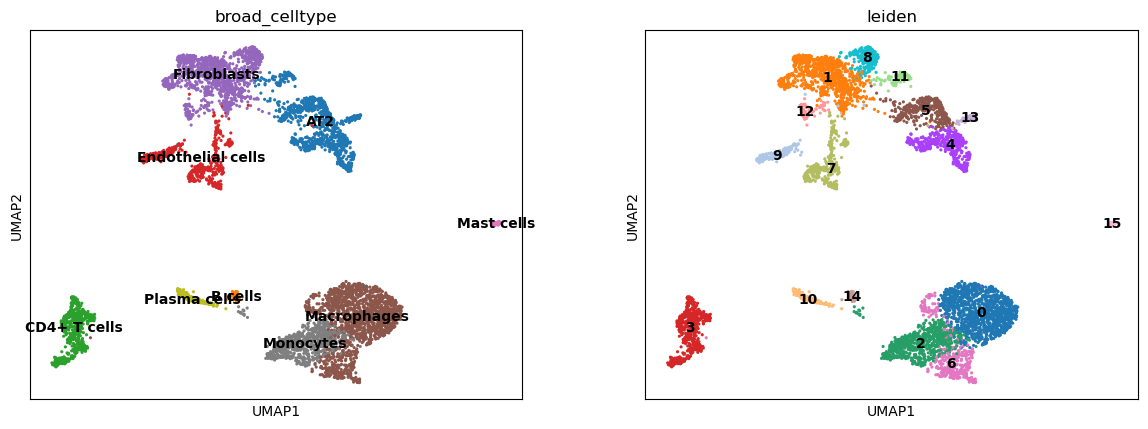

=== [GSM5226586_L06cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226586_L06cov.raw.processed.h5ad (55.1 MB) ===

=== [GSM5226587_L07cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226587_L07cov.raw.h5ad ===

=== [GSM5226587_L07cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226587_L07cov kept 4201/5074 | max_genes=4075, max_counts=9843, max_mito=6.14
[QC filter] removed 873 cells; remaining 4201
Running Scrublet for doublet detection...
Removed 19 predicted doublets
After doublet removal: (4182, 23003)
[steps] 01/03 preprocess_to_pca: done (8.35s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (4.21s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.43s)

### Sample: GSM5226587_L07cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


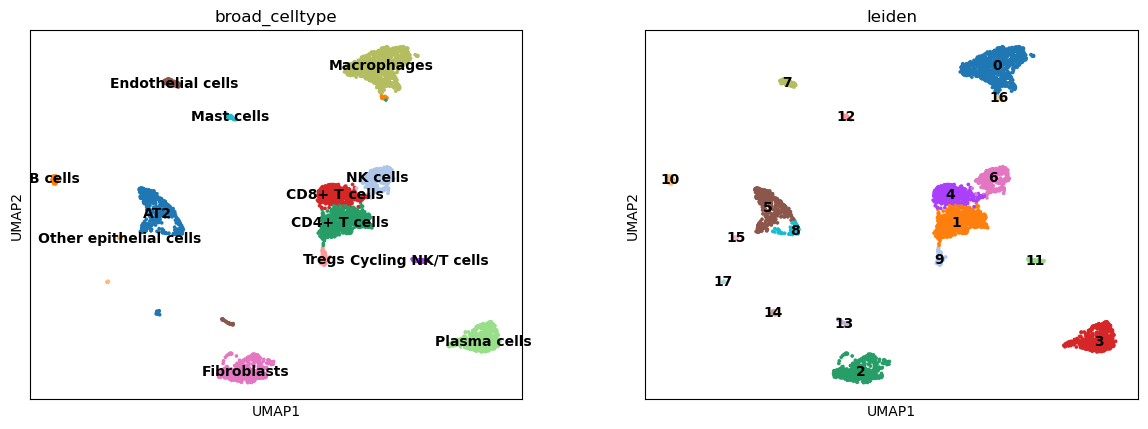

=== [GSM5226587_L07cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226587_L07cov.raw.processed.h5ad (43.5 MB) ===

=== [GSM5226588_L08cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226588_L08cov.raw.h5ad ===

=== [GSM5226588_L08cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226588_L08cov kept 3476/4149 | max_genes=3572, max_counts=7893, max_mito=3.25
[QC filter] removed 673 cells; remaining 3476
Running Scrublet for doublet detection...
Removed 4 predicted doublets
After doublet removal: (3472, 22995)
[steps] 01/03 preprocess_to_pca: done (6.72s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.99s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.36s)

### Sample: GSM5226588_L08cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


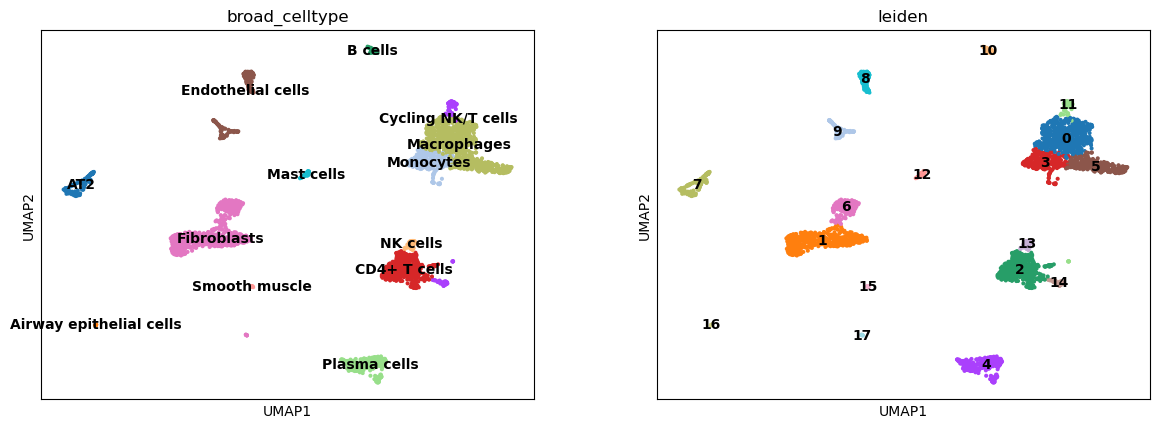

=== [GSM5226588_L08cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226588_L08cov.raw.processed.h5ad (36.5 MB) ===

=== [GSM5226589_L09cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226589_L09cov.raw.h5ad ===

=== [GSM5226589_L09cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226589_L09cov kept 2747/3605 | max_genes=3437, max_counts=6135, max_mito=7.09
[QC filter] removed 858 cells; remaining 2747
Running Scrublet for doublet detection...
Removed 20 predicted doublets
After doublet removal: (2727, 21859)
[steps] 01/03 preprocess_to_pca: done (5.30s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.23s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.28s)

### Sample: GSM5226589_L09cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


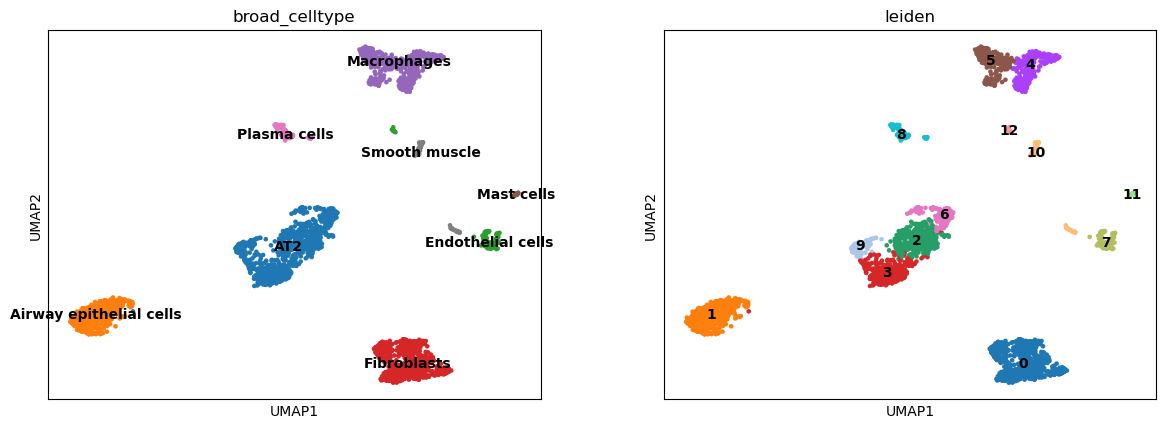

=== [GSM5226589_L09cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226589_L09cov.raw.processed.h5ad (23.7 MB) ===

=== [GSM5226590_L10cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226590_L10cov.raw.h5ad ===

=== [GSM5226590_L10cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226590_L10cov kept 1129/1550 | max_genes=2259, max_counts=4193, max_mito=6.09
[QC filter] removed 421 cells; remaining 1129
Running Scrublet for doublet detection...
Removed 3 predicted doublets
After doublet removal: (1126, 17640)
[steps] 01/03 preprocess_to_pca: done (0.45s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (0.90s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.14s)

### Sample: GSM5226590_L10cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


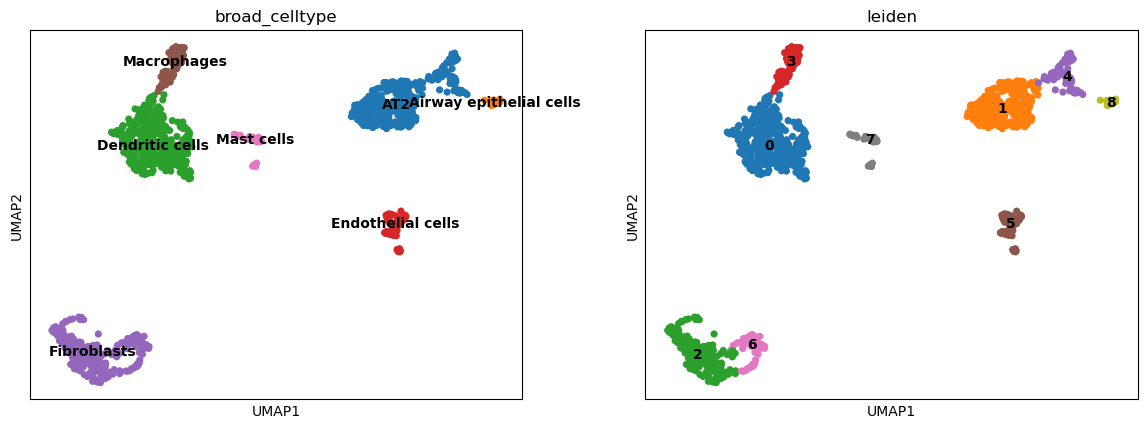

=== [GSM5226590_L10cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226590_L10cov.raw.processed.h5ad (10.0 MB) ===

=== [GSM5226591_L11cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226591_L11cov.raw.h5ad ===

=== [GSM5226591_L11cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226591_L11cov kept 2740/3296 | max_genes=3619, max_counts=8167, max_mito=2.84
[QC filter] removed 556 cells; remaining 2740
Running Scrublet for doublet detection...
Removed 4 predicted doublets
After doublet removal: (2736, 20302)
[steps] 01/03 preprocess_to_pca: done (5.27s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.25s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.30s)

### Sample: GSM5226591_L11cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


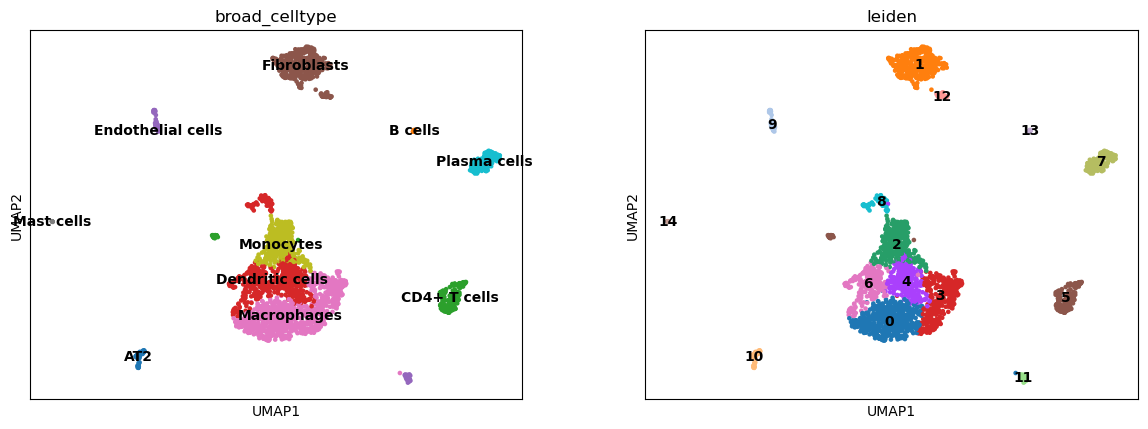

=== [GSM5226591_L11cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226591_L11cov.raw.processed.h5ad (29.4 MB) ===

=== [GSM5226592_L12cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226592_L12cov.raw.h5ad ===

=== [GSM5226592_L12cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226592_L12cov kept 3019/3876 | max_genes=4174, max_counts=9429, max_mito=3.23
[QC filter] removed 857 cells; remaining 3019
Running Scrublet for doublet detection...
Removed 11 predicted doublets
After doublet removal: (3008, 22181)
[steps] 01/03 preprocess_to_pca: done (5.90s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.51s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.32s)

### Sample: GSM5226592_L12cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


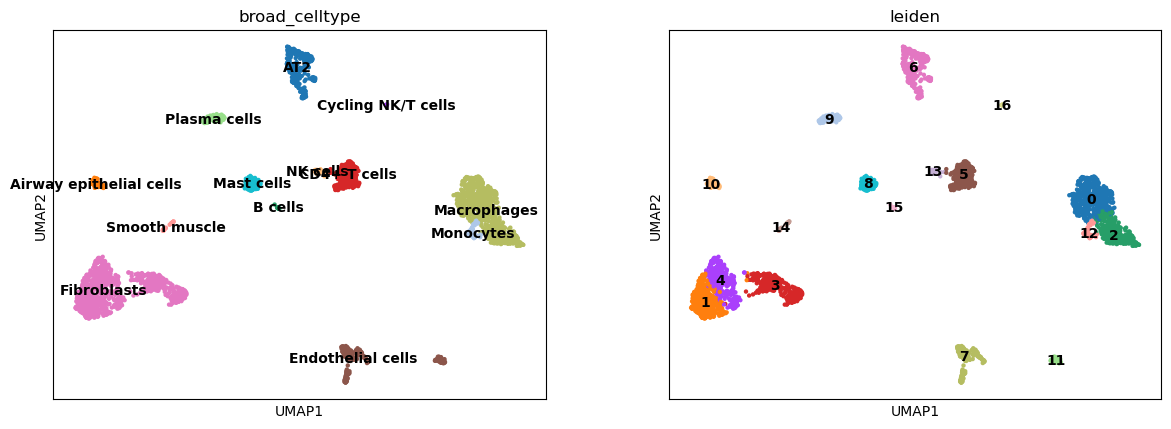

=== [GSM5226592_L12cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226592_L12cov.raw.processed.h5ad (29.1 MB) ===

=== [GSM5226593_L13cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226593_L13cov.raw.h5ad ===

=== [GSM5226593_L13cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226593_L13cov kept 4035/4862 | max_genes=3729, max_counts=9563, max_mito=3.03
[QC filter] removed 827 cells; remaining 4035
Running Scrublet for doublet detection...
Removed 6 predicted doublets
After doublet removal: (4029, 23171)
[steps] 01/03 preprocess_to_pca: done (7.64s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (3.38s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.41s)

### Sample: GSM5226593_L13cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


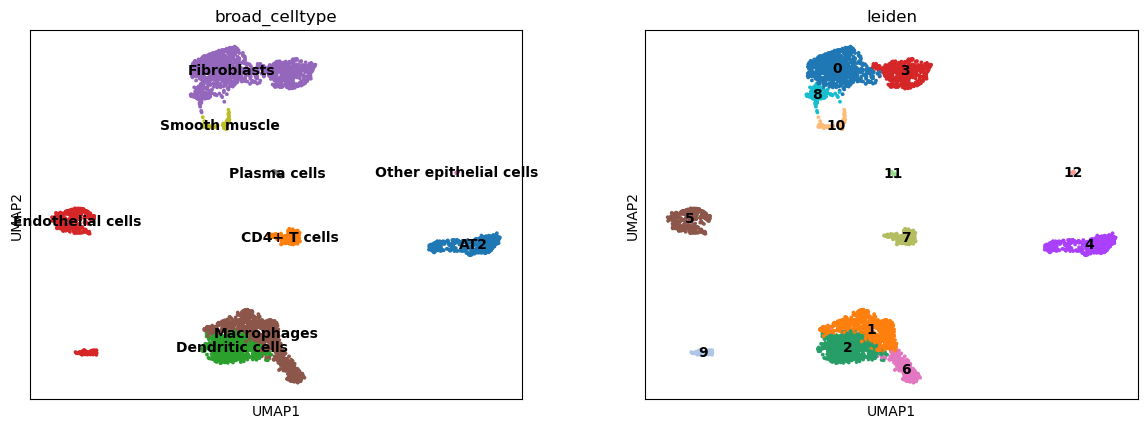

=== [GSM5226593_L13cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226593_L13cov.raw.processed.h5ad (41.2 MB) ===

=== [GSM5226594_L15cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226594_L15cov.raw.h5ad ===

=== [GSM5226594_L15cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226594_L15cov kept 3262/4056 | max_genes=2963, max_counts=6015, max_mito=7.63
[QC filter] removed 794 cells; remaining 3262
Running Scrublet for doublet detection...
Removed 35 predicted doublets
After doublet removal: (3227, 22193)
[steps] 01/03 preprocess_to_pca: done (6.08s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.69s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.32s)

### Sample: GSM5226594_L15cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


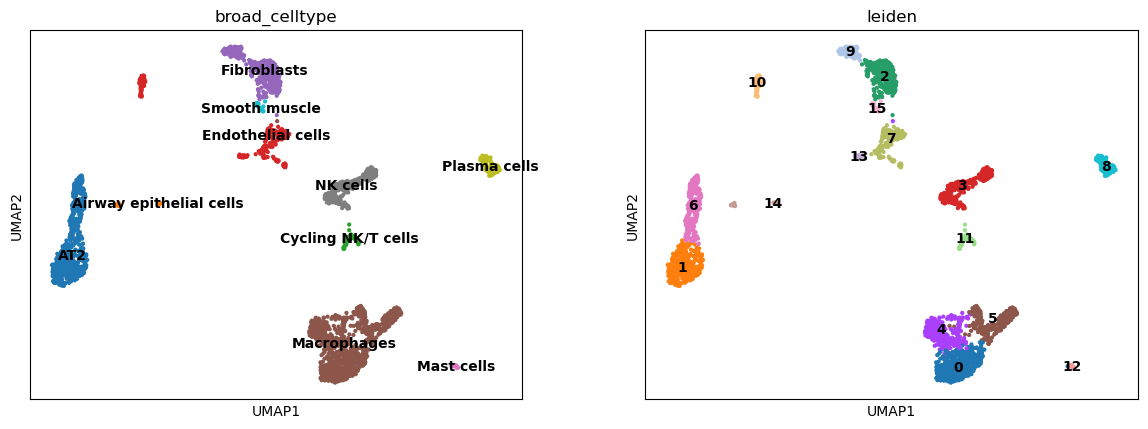

=== [GSM5226594_L15cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226594_L15cov.raw.processed.h5ad (31.0 MB) ===

=== [GSM5226595_L16cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226595_L16cov.raw.h5ad ===

=== [GSM5226595_L16cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226595_L16cov kept 1374/1822 | max_genes=3032, max_counts=6627, max_mito=7.37
[QC filter] removed 448 cells; remaining 1374
Running Scrublet for doublet detection...
Removed 4 predicted doublets
After doublet removal: (1370, 19457)
[steps] 01/03 preprocess_to_pca: done (0.64s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (1.09s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.19s)

### Sample: GSM5226595_L16cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


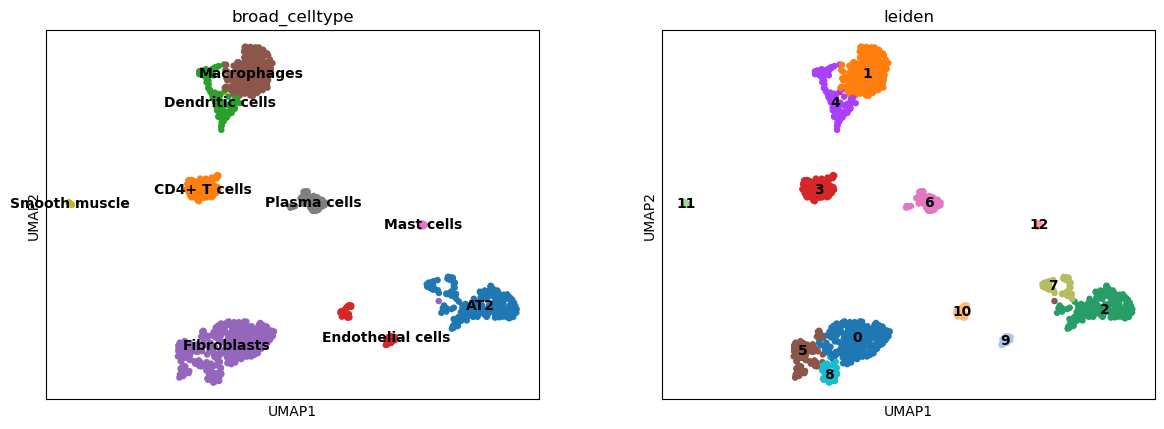

=== [GSM5226595_L16cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226595_L16cov.raw.processed.h5ad (13.9 MB) ===

=== [GSM5226596_L17cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226596_L17cov.raw.h5ad ===

=== [GSM5226596_L17cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226596_L17cov kept 3698/4651 | max_genes=3031, max_counts=6736, max_mito=2.09
[QC filter] removed 953 cells; remaining 3698
Running Scrublet for doublet detection...
Removed 10 predicted doublets
After doublet removal: (3688, 22669)
[steps] 01/03 preprocess_to_pca: done (6.87s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (3.06s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.35s)

### Sample: GSM5226596_L17cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


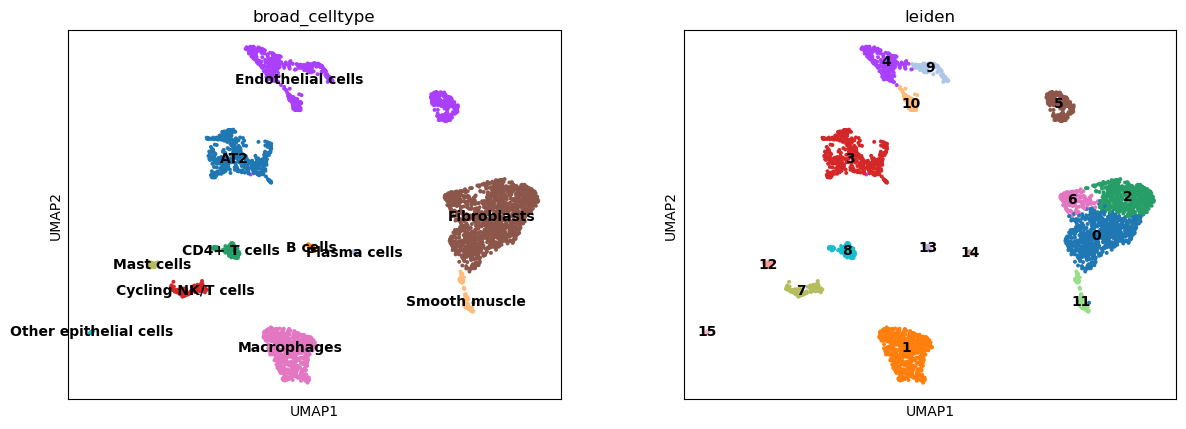

=== [GSM5226596_L17cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226596_L17cov.raw.processed.h5ad (34.2 MB) ===

=== [GSM5226597_L18cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226597_L18cov.raw.h5ad ===

=== [GSM5226597_L18cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226597_L18cov kept 1814/2816 | max_genes=1490, max_counts=2378, max_mito=3.85
[QC filter] removed 1002 cells; remaining 1814
Running Scrublet for doublet detection...
Removed 12 predicted doublets
After doublet removal: (1802, 17193)
[steps] 01/03 preprocess_to_pca: done (0.66s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (1.46s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.16s)

### Sample: GSM5226597_L18cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


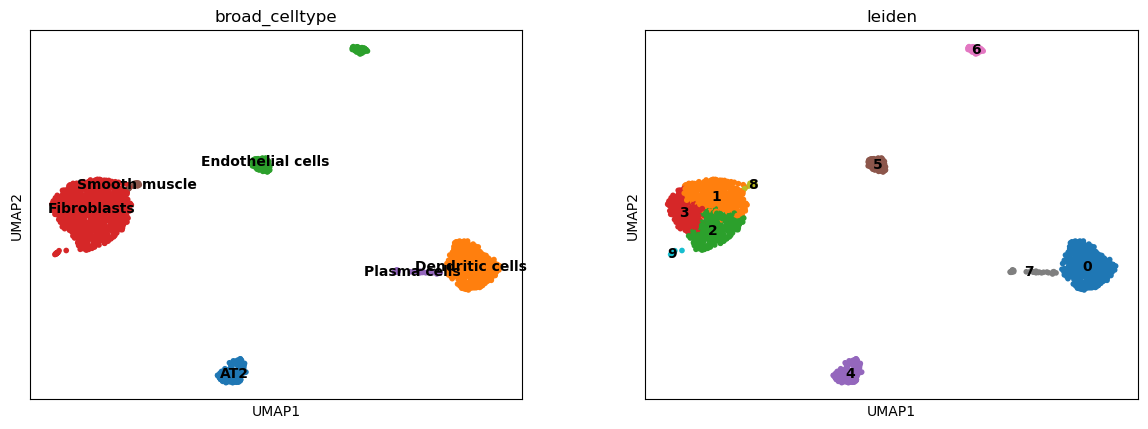

=== [GSM5226597_L18cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226597_L18cov.raw.processed.h5ad (12.2 MB) ===

=== [GSM5226598_L19cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226598_L19cov.raw.h5ad ===

=== [GSM5226598_L19cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226598_L19cov kept 2064/2509 | max_genes=2981, max_counts=6915, max_mito=7.31
[QC filter] removed 445 cells; remaining 2064
Running Scrublet for doublet detection...
Removed 6 predicted doublets
After doublet removal: (2058, 20164)
[steps] 01/03 preprocess_to_pca: done (0.90s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (1.72s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.25s)

### Sample: GSM5226598_L19cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


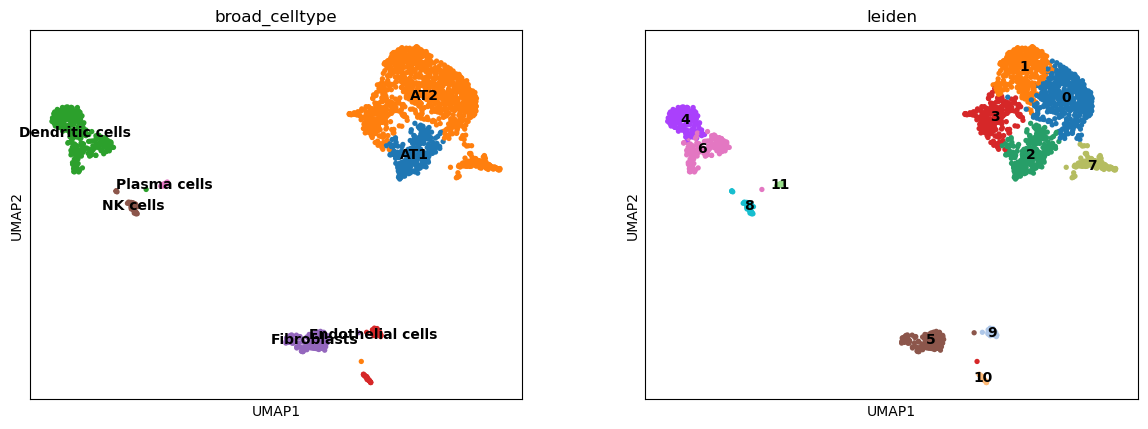

=== [GSM5226598_L19cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226598_L19cov.raw.processed.h5ad (22.4 MB) ===

=== [GSM5226599_L21cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226599_L21cov.raw.h5ad ===

=== [GSM5226599_L21cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226599_L21cov kept 2582/3425 | max_genes=2655, max_counts=5515, max_mito=7.57
[QC filter] removed 843 cells; remaining 2582
Running Scrublet for doublet detection...
Removed 6 predicted doublets
After doublet removal: (2576, 19918)
[steps] 01/03 preprocess_to_pca: done (1.19s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (2.18s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.26s)

### Sample: GSM5226599_L21cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


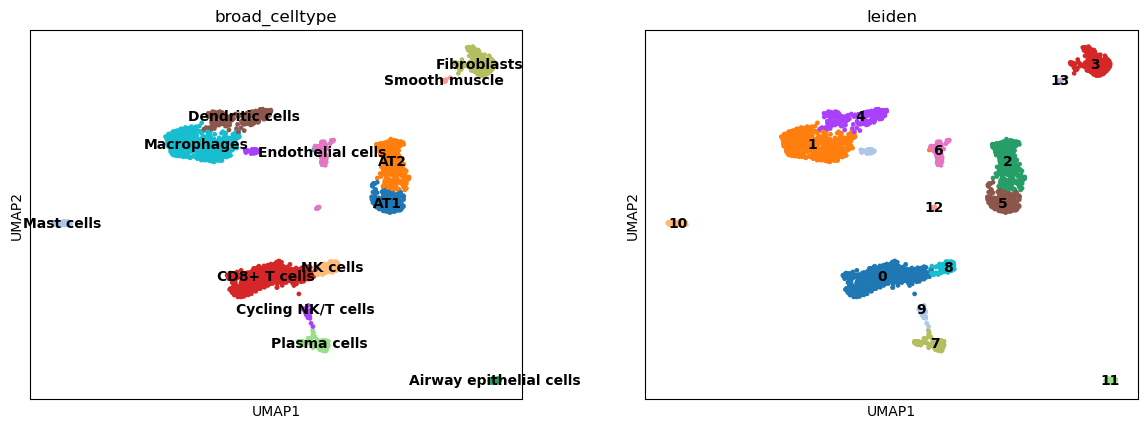

=== [GSM5226599_L21cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226599_L21cov.raw.processed.h5ad (21.4 MB) ===

=== [GSM5226600_L22cov.raw] loading: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw/GSM5226600_L22cov.raw.h5ad ===

=== [GSM5226600_L22cov.raw] running standard_per_sample_pipeline ===
[steps] 01/03 preprocess_to_pca: start
[QC filter] batch=GSM5226600_L22cov kept 5502/6987 | max_genes=2870, max_counts=6118, max_mito=3.87
[QC filter] removed 1485 cells; remaining 5502
Running Scrublet for doublet detection...
Removed 13 predicted doublets
After doublet removal: (5489, 23170)
[steps] 01/03 preprocess_to_pca: done (10.05s)
[steps] 02/03 cluster_and_embed: start
[steps] 02/03 cluster_and_embed: done (5.23s)
[steps] 03/03 broad_annotation: start
[steps] 03/03 broad_annotation: done (0.46s)

### Sample: GSM5226600_L22cov.raw


/Users/alahi.irfan/Desktop/Local_workspace/scRNA-seq-pipeline/scrna_pipeline/steps/annotation.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_key)[score_cols]


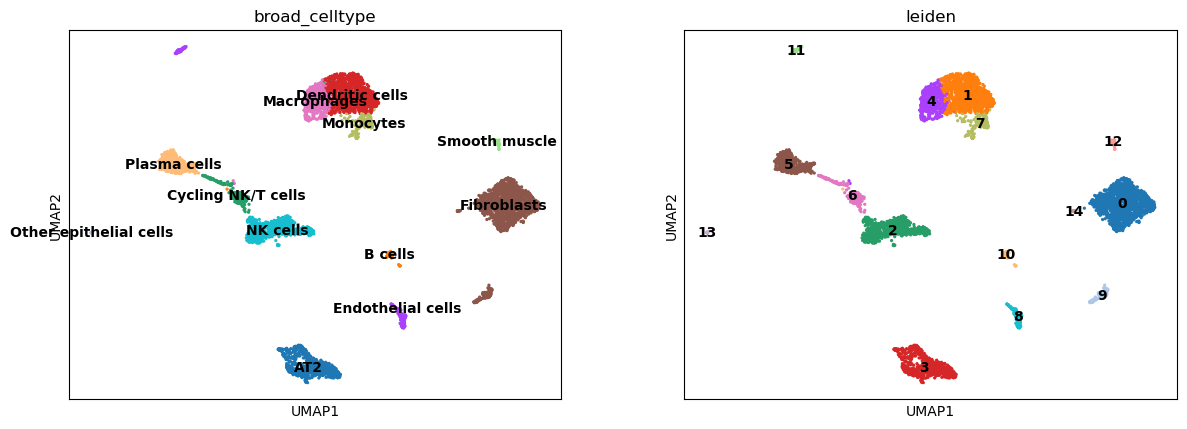

=== [GSM5226600_L22cov.raw] saved: /Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed/GSM5226600_L22cov.raw.processed.h5ad (48.3 MB) ===


In [85]:

from pathlib import Path

from scrna_pipeline.core.batch_runner import (
    BatchRunConfig,
    run_pipeline_on_batch,
    run_pipeline_on_h5ad_folder,
    constant_kwargs_factory,
)
from scrna_pipeline.pipelines.standard_per_sample import standard_per_sample_pipeline


# 2) Same pipeline kwargs for every sample
kwargs_factory = constant_kwargs_factory({
    "batch_key": "batch",           # must exist in each adata.obs
    "marker_dict": BROAD_MARKERS,   # dict[str, list[str]]
})

cfg = BatchRunConfig(
    out_dir=Path("/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed"),
    strip_graph=True,      # remove neighbors graph before saving
    keep_umap=True,        # keep X_umap
    keep_pca=True,         # keep X_pca
    compression="gzip",
    verbose=True,
    strict=True,
)

saved = run_pipeline_on_h5ad_folder(
    "/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_raw",
    pipeline=standard_per_sample_pipeline,
    kwargs_factory=kwargs_factory,
    config=cfg,
    delete_inputs=False,   # deletes raw only after successful save
    on_sample_done=show_umap_summary,  # or None
)

# Integration

In [86]:

import scanpy as sc
from anndata import AnnData

def add_umap_from_rep(
     adata: AnnData,
     *,
     rep_key: str,
     umap_key: str,
     neighbors_key: str,
     n_neighbors: int = 15,
     metric: str = "cosine",
     min_dist: float = 0.5,
     spread: float = 1.0,
     random_state: int = 0,
 ) -> None:
    if rep_key not in adata.obsm:
         raise KeyError(f"{rep_key!r} not found in adata.obsm")
    sc.pp.neighbors(
         adata,
         use_rep=rep_key,
         n_neighbors=n_neighbors,
         metric=metric,
         key_added=neighbors_key,
     )
    sc.tl.umap(
         adata,
         neighbors_key=neighbors_key,
         min_dist=min_dist,
         spread=spread,
         random_state=random_state,
     )
     # Move Scanpy's default 'X_umap' to a custom key
    adata.obsm[umap_key] = adata.obsm["X_umap"].copy()
    del adata.obsm["X_umap"]

from anndata import AnnData

def add_pre_post_umaps(a: AnnData, *, batch_method: str) -> None:
    pre_umap_key = "X_umap_pre_BatchCorrection"
    pre_neighbors_key = "neighbors_pre_BatchCorrection"

    if pre_umap_key not in a.obsm:
        add_umap_from_rep(
            a,
            rep_key="X_pca",
            umap_key=pre_umap_key,
            neighbors_key=pre_neighbors_key,
        )

    if batch_method == "none":
        return

    rep_key = f"X_pca_{batch_method}"
    post_umap_key = f"X_umap_post_BatchCorrection_{batch_method}"
    post_neighbors_key = f"neighbors_post_BatchCorrection_{batch_method}"

    if rep_key not in a.obsm:
        raise RuntimeError(f"batch_method != 'none' but {rep_key} is missing.")

    if post_umap_key not in a.obsm:
        add_umap_from_rep(
            a,
            rep_key=rep_key,
            umap_key=post_umap_key,
            neighbors_key=post_neighbors_key,
        )









from scrna_pipeline.pipelines.integration_from_processed_samples import integration_from_processed_samples_pipeline

from scrna_pipeline.core.integration_runner import run_integration_pipeline, IntegrationRunConfig

adata_int = run_integration_pipeline(
     pipeline=integration_from_processed_samples_pipeline,
     pipeline_kwargs=dict(
         folder="/Users/alahi.irfan/Desktop/Local_workspace/Data/Melms_Nature_2021/per_sample_processed",
        batch_key="sample_id",         batch_method="harmony",
    ),
    postprocess=lambda a: add_pre_post_umaps(a, batch_method="harmony"),
    config=IntegrationRunConfig(out_path=None),
)



[steps] 01/03 combine_samples: start
[steps] 01/03 combine_samples: done (13.59s)
[steps] 02/03 build_embedding_pca: start


2026-01-14 11:22:44,510 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


[steps] 02/03 build_embedding_pca: done (2.91s)
[steps] 03/03 batch_correction: start
Running Harmony batch correction using batch_key='sample_id'...


2026-01-14 11:22:47,761 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-01-14 11:22:47,909 - harmonypy - INFO - Iteration 1 of 10
2026-01-14 11:23:01,014 - harmonypy - INFO - Iteration 2 of 10
2026-01-14 11:39:11,613 - harmonypy - INFO - Iteration 3 of 10
2026-01-14 11:39:26,214 - harmonypy - INFO - Iteration 4 of 10
2026-01-14 11:39:40,005 - harmonypy - INFO - Iteration 5 of 10
2026-01-14 11:47:02,900 - harmonypy - INFO - Iteration 6 of 10
2026-01-14 11:47:21,683 - harmonypy - INFO - Iteration 7 of 10
2026-01-14 11:47:34,016 - harmonypy - INFO - Iteration 8 of 10
2026-01-14 11:47:42,501 - harmonypy - INFO - Iteration 9 of 10
2026-01-14 11:47:49,621 - harmonypy - INFO - Iteration 10 of 10
2026-01-14 11:47:56,243 - harmonypy - INFO - Stopped before convergence


[steps] 03/03 batch_correction: done (1511.77s)


In [87]:
print(adata_int)

AnnData object with n_obs × n_vars = 92587 × 29602
    obs: 'sample', 'file', 'batch', 'sample_id', 'broad_Airway epithelial cells_score', 'broad_AT1_score', 'broad_AT2_score', 'broad_Other epithelial cells_score', 'broad_B cells_score', 'broad_Plasma cells_score', 'broad_CD4+ T cells_score', 'broad_CD8+ T cells_score', 'broad_Tregs_score', 'broad_NK cells_score', 'broad_Cycling NK/T cells_score', 'broad_Monocytes_score', 'broad_Macrophages_score', 'broad_Dendritic cells_score', 'broad_Mast cells_score', 'broad_Fibroblasts_score', 'broad_Smooth muscle_score', 'broad_Endothelial cells_score', 'broad_Neuronal cells_score', 'broad_celltype'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'scrna_pipeline', 'hvg', 'pca', 'neighbors_pre_BatchCorrection', 'umap', 'neighbors_post_BatchCorrection_harmony'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap_pre_BatchCorrection', 'X_umap_post_BatchCorrection_harmony'
    laye

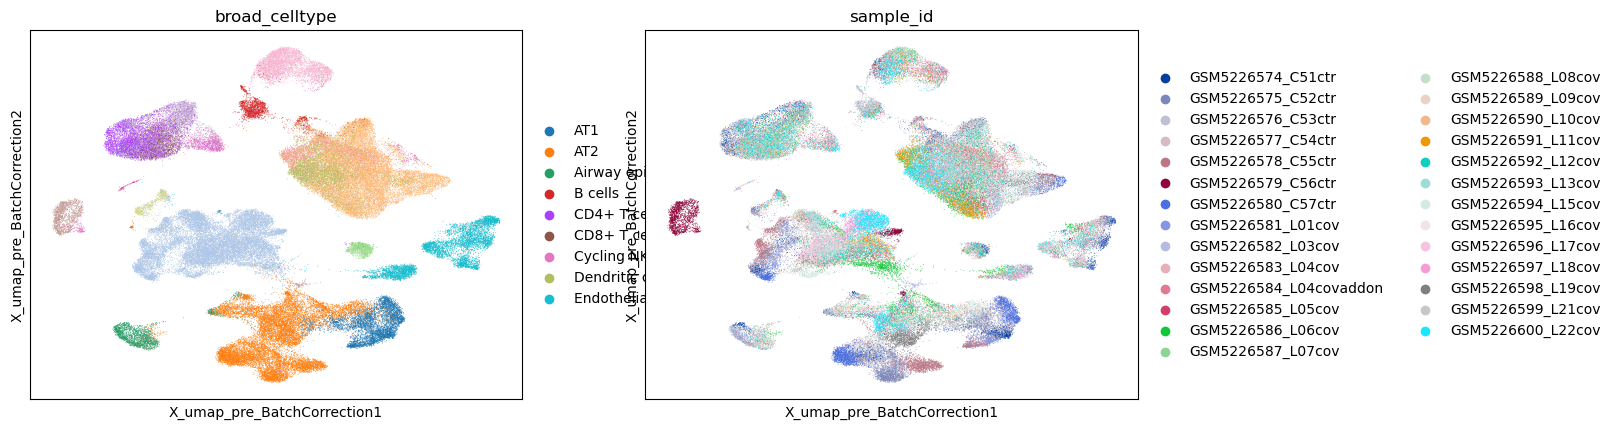

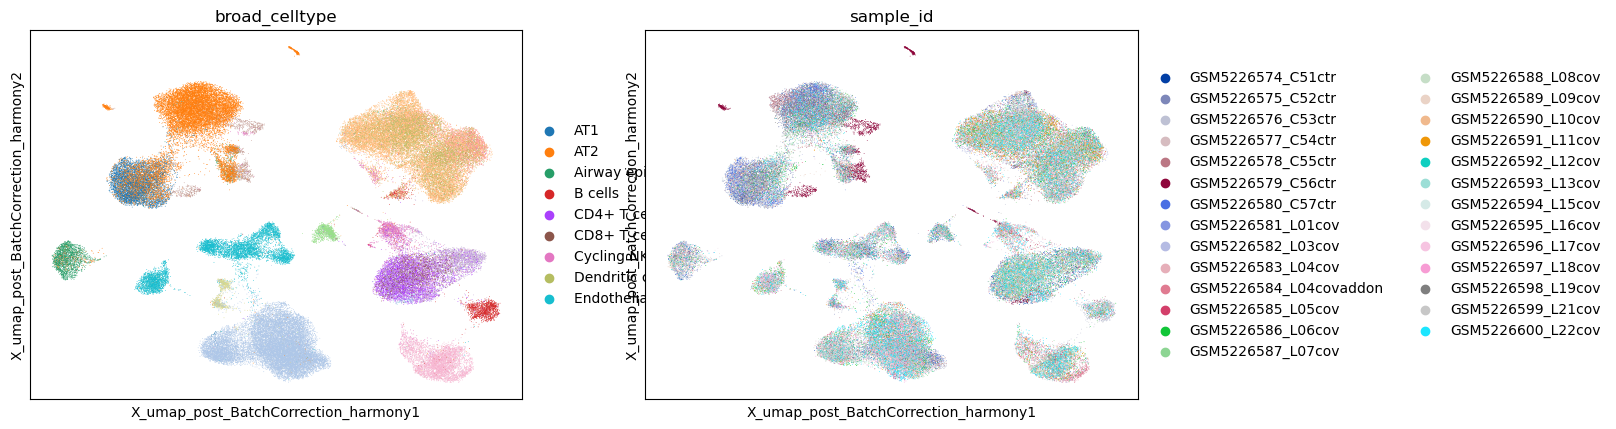

In [88]:
sc.pl.embedding(adata_int, basis="X_umap_pre_BatchCorrection",  color=["broad_celltype", "sample_id"])
sc.pl.embedding(adata_int, basis="X_umap_post_BatchCorrection_harmony", color=["broad_celltype", "sample_id"])

✔ Added 'sample_type' to adata.obs


/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_2678/1805523030.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(sample_col)[sample_type_col]
/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_2678/1805523030.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([sample_col, celltype_col])
/var/folders/mr/gbhgcyxx2yz6w_nj9nmtr2nc0000gr/T/ipykernel_2678/1805523030.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

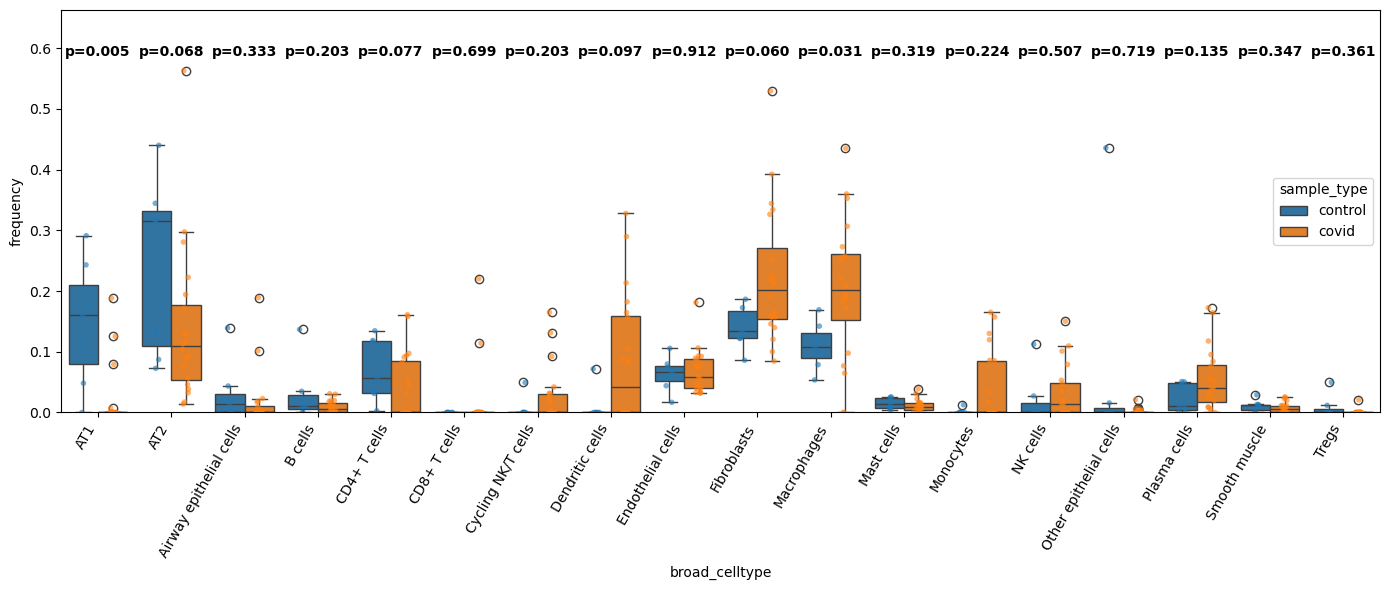

In [89]:
import pandas as pd
from anndata import AnnData

import numpy as np

def assign_sample_type(adata, sample_col="sample", new_col="sample_type"):
    samples = adata.obs[sample_col].astype(str)

    # Conditions
    is_ctr = samples.str.contains("ctr", case=False, regex=False)
    is_cov = samples.str.contains("cov", case=False, regex=False)

    # Check for invalid samples
    invalid = ~(is_ctr | is_cov)
    if invalid.any():
        bad = samples[invalid].tolist()
        raise ValueError(f"❌ Unrecognized sample names (neither 'ctr' nor 'cov'): {bad}")

    # Assign values
    adata.obs[new_col] = np.where(is_ctr, "control", "covid")

    print(f"✔ Added '{new_col}' to adata.obs")
    return adata

def compute_celltype_freq_per_sample(
    adata: AnnData,
    sample_col: str = "sample",           # e.g. GSM5226574_C51ctr
    sample_type_col: str = "sample_type", # e.g. "control" / "covid"
    celltype_col: str = "celltype",
) -> pd.DataFrame:
    """
    Compute per-sample cell type frequencies from an AnnData object.

    For each (sample, celltype) pair, this function counts how many cells
    belong to that cell type within the sample, computes the total number
    of cells in the sample, and returns:

        frequency = n_cells / total_cells

    Includes the sample_type (e.g. "control" or "covid") for each sample.
    """

    # Extract only the columns required for computation
    df = adata.obs[[sample_col, sample_type_col, celltype_col]].copy()

    # ------------------------------------------------------------------
    # 🔍 SANITY CHECK — ensure each sample has EXACTLY ONE sample_type
    # ------------------------------------------------------------------
    # Count distinct sample_type values per sample
    type_counts = (
        df.groupby(sample_col)[sample_type_col]
        .nunique()
        .rename("n_types")
    )

    # Detect problematic samples
    bad_samples = type_counts[type_counts > 1]

    if len(bad_samples) > 0:
        msg_lines = [
            "❌ ERROR: Some samples have MORE THAN ONE sample_type.",
            "Each sample must belong to exactly one sample_type.",
            "",
            "Problematic samples:",
        ]
        for s in bad_samples.index:
            unique_types = df.loc[df[sample_col] == s, sample_type_col].unique()
            msg_lines.append(f"  - {s}: {list(unique_types)}")
        msg = "\n".join(msg_lines)
        raise ValueError(msg)

    # ------------------------------------------------------------------
    # 1) Count cells for each (sample, celltype)
    # ------------------------------------------------------------------
    counts = (
        df.groupby([sample_col, celltype_col])
          .size()
          .rename("n_cells")
          .reset_index()
    )

    # ------------------------------------------------------------------
    # 2) Total cells per sample
    # ------------------------------------------------------------------
    totals = (
        df.groupby(sample_col)
          .size()
          .rename("total_cells")
          .reset_index()
    )

    # ------------------------------------------------------------------
    # 3) Merge and compute frequency per cell type
    # ------------------------------------------------------------------
    freq = counts.merge(totals, on=sample_col, how="left")
    freq["frequency"] = freq["n_cells"] / freq["total_cells"]

    # ------------------------------------------------------------------
    # 4) Add sample_type column back to frequency table
    # ------------------------------------------------------------------
    sample_to_type = (
        df[[sample_col, sample_type_col]]
        .drop_duplicates()
        .set_index(sample_col)[sample_type_col]
    )

    freq["sample_type"] = freq[sample_col].map(sample_to_type)

    return freq

import pandas as pd
from scipy.stats import ranksums


def compute_groupwise_wilcoxon(
    data: pd.DataFrame,
    group_col: str,
    value_col: str,
    category_col: str | None = None,
):
    """
    Compute Wilcoxon rank-sum p-values between TWO groups in `group_col`.

    If `category_col` is provided:
        - Perform a separate test for each category (e.g. each cell type).
        - Returns a dict: {category_value -> p-value or None}.

    If `category_col` is None:
        - Perform a SINGLE test over the entire DataFrame.
        - Returns a single float p-value.

    Parameters
    ----------
    data : pd.DataFrame
        Input table containing at least `group_col` and `value_col`,
        and optionally `category_col`.
    group_col : str
        Column name indicating the group labels (must have exactly 2 groups).
    value_col : str
        Column name with the numeric values to compare.
    category_col : str or None, default None
        If given, compute one p-value per category in this column.
        If None, compute a single p-value over all rows.

    Returns
    -------
    pvals : dict or float
        - dict if `category_col` is not None: {category -> p-value or None}
        - float if `category_col` is None: a single p-value
    """
    # Ensure exactly two groups are present
    groups = data[group_col].dropna().unique()
    if len(groups) != 2:
        raise ValueError(
            f"Wilcoxon rank-sum requires exactly 2 groups in '{group_col}', "
            f"but found {len(groups)}: {groups}"
        )
    g1, g2 = groups

    # Case 1: no category_col → single global test
    if category_col is None:
        x = data[data[group_col] == g1][value_col].values
        y = data[data[group_col] == g2][value_col].values

        if len(x) == 0 or len(y) == 0:
            return None

        stat, p = ranksums(x, y)
        return p

    # Case 2: groupwise tests per category
    pvals: dict = {}

    for cat in data[category_col].unique():
        sub = data[data[category_col] == cat]

        x = sub[sub[group_col] == g1][value_col].values
        y = sub[sub[group_col] == g2][value_col].values

        if len(x) > 0 and len(y) > 0:
            stat, p = ranksums(x, y)
            pvals[cat] = p
        else:
            # If one of the groups is missing for this category
            pvals[cat] = None

    return pvals


import seaborn as sns
import matplotlib.pyplot as plt


def plot_grouped_boxplot_with_pvalues(
    data: pd.DataFrame,
    x_col: str,          # category on x-axis (e.g. "celltype")
    y_col: str,          # numeric value (e.g. "frequency")
    hue_col: str,        # group column (e.g. "sample_type")
    figsize=(14, 6),
    add_strip: bool = True,
    jitter_alpha: float = 0.6,
    jitter_size: int = 4,
    pvalue_y_offset: float = 0.02,
):
    """
    Make a boxplot (optionally with jittered points) for y_col ~ x_col,
    colored by hue_col, and annotate each x-category with a Wilcoxon
    rank-sum p-value comparing the two hue groups.

    Parameters
    ----------
    data : pd.DataFrame
        Long-format DataFrame containing at least [x_col, y_col, hue_col].
    x_col : str
        Column name for categories on the x-axis.
    y_col : str
        Column name for numeric values on the y-axis.
    hue_col : str
        Column name for the grouping variable used as hue (must have 2 groups).
    figsize : tuple, default (14, 6)
        Figure size passed to matplotlib.
    add_strip : bool, default True
        Whether to overlay individual data points as a stripplot.
    jitter_alpha : float, default 0.6
        Transparency for stripplot points.
    jitter_size : int, default 4
        Size of stripplot points.
    pvalue_y_offset : float, default 0.02
        Vertical offset above the max y-value for placing p-value labels.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The Axes object of the generated plot.
    """
    # -------------------------------------------------------------
    # 1) Compute Wilcoxon p-values per x-category
    # -------------------------------------------------------------
    pvals = compute_groupwise_wilcoxon(
        data=data,
        group_col=hue_col,
        value_col=y_col,
        category_col=x_col,
    )

    # -------------------------------------------------------------
    # 2) Make the boxplot (and optional stripplot)
    # -------------------------------------------------------------
    plt.figure(figsize=figsize)
    ax = plt.gca()

    sns.boxplot(
        data=data,
        x=x_col,
        y=y_col,
        hue=hue_col,
        dodge=True,
        ax=ax,
    )

    if add_strip:
        sns.stripplot(
            data=data,
            x=x_col,
            y=y_col,
            hue=hue_col,
            dodge=True,
            alpha=jitter_alpha,
            size=jitter_size,
            ax=ax,
        )

    # Rotate x-axis labels for readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha="right")

    ax.set_ylabel(y_col)
    plt.tight_layout()

    # Avoid double legend (box + strip both add entries)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title=hue_col)

    # -------------------------------------------------------------
    # 3) Add p-value annotations above each x-category
    # -------------------------------------------------------------
    max_y = data[y_col].max()
    categories = data[x_col].unique()

    for i, cat in enumerate(categories):
        p = pvals.get(cat, None)

        if p is None:
            text = "n/a"
        else:
            text = f"p={p:.3e}" if p < 0.001 else f"p={p:.3f}"

        ax.text(
            i,                         # x-position (category index)
            max_y + pvalue_y_offset,   # y-position
            text,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    # Add headroom so labels are visible
    ax.set_ylim(0, max_y + pvalue_y_offset * 5)

    return ax



assign_sample_type(adata_int)

freq = compute_celltype_freq_per_sample(adata=adata_int, sample_col='sample',sample_type_col='sample_type',celltype_col='broad_celltype')

ax = plot_grouped_boxplot_with_pvalues(
    data=freq,
    x_col="broad_celltype",
    y_col="frequency",
    hue_col="sample_type",
)
plt.show()